In [1]:
# 1 Importation des bibliothèques

## lecture, sélection, manipulation, transformation des données (csv, json, excel)
import pandas as pd

## algèbre et calculs statistiques (moyenne, médiane, écart-type, quantiles)
import numpy as np

## visualisation de données (tableaux, graphiques, histogrammes)
### Graphiques personnalisés (plus de code requis)
import matplotlib.pyplot as plt
### Graphiques esthétiques (peu de code requis)
import seaborn as sns

## contrôle des avertissements et messages d'erreur (dépollution visuelle)
import warnings

## manipulation Json
import json

## manipulation de fichiers et de chemins d'accès (lecture, écriture, vérification d'existence)
import os

import joblib

import tensorflow as tf
import keras

import shap

import optuna
from sklearn.utils.class_weight import compute_class_weight

## garantir la reproductibilité des résultats (porpotions de données, initialisation aléatoire)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (confusion_matrix, roc_curve, auc, 
                             precision_recall_curve, f1_score, fbeta_score,
                             classification_report, average_precision_score)

warnings.filterwarnings('ignore')

# Configuration des chemins
DOSSIER_RACINE = 'RN_sous_doss'
DOSSIER_MODELES = os.path.join(DOSSIER_RACINE, 'models')
DOSSIER_LOGS = os.path.join(DOSSIER_RACINE, 'logs')
os.makedirs(DOSSIER_MODELES, exist_ok=True)
os.makedirs(DOSSIER_LOGS, exist_ok=True)

DOSSIER_TF = os.path.join(DOSSIER_RACINE, 'data_tf_pipelines')
DOSSIER_TRANSFORMED = os.path.join(DOSSIER_RACINE, 'data_transformed')

def valider_environnement():
    """Vérifie l'accès aux ressources de calcul et la création des dossiers."""
    assert os.path.exists(DOSSIER_MODELES), "Erreur : Dossier des modèles non créé."
    assert os.path.exists(DOSSIER_LOGS), "Erreur : Dossier des logs non créé."
    print("Environnement TensorFlow version :", tf.__version__)
    print("Périphériques disponibles :", tf.config.list_physical_devices())

valider_environnement()

print("Environnement d'évaluation configuré. TensorFlow version:", tf.__version__)

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
# Chargement, préparation et partitionnement des données
df = pd.read_csv('Loan_default.csv', sep=';')

if 'LoanID' in df.columns:
    df = df.drop(columns=['LoanID'])

cible = 'Default'

df_temp, df_test = train_test_split(df, test_size=0.15, stratify=df[cible], random_state=42)
df_train, df_val = train_test_split(df_temp, test_size=0.1765, stratify=df_temp[cible], random_state=42)

colonnes_continues = df.select_dtypes(include=['float64', 'int64']).columns.drop(cible, errors='ignore').tolist()
colonnes_categorielles = df.select_dtypes(include=['object', 'category']).columns.tolist()

ensembles = {
    'train': df_train.copy(), 
    'val': df_val.copy(), 
    'test': df_test.copy()
}

print(f"Dimensions - Entrainement: {ensembles['train'].shape}, Validation: {ensembles['val'].shape}, Test: {ensembles['test'].shape}")

Dimensions - Entrainement: (178735, 17), Validation: (38309, 17), Test: (38303, 17)


In [ ]:
#Traitement des valeurs manquantes et imputation
valeurs_imputation = {'continues': {}, 'categorielles': {}}
dictionnaire_fillna = {}

for col in colonnes_continues:
    mediane = float(ensembles['train'][col].median())
    valeurs_imputation['continues'][col] = mediane
    dictionnaire_fillna[col] = mediane

for col in colonnes_categorielles:
    mode_val = str(ensembles['train'][col].mode().iloc[0])
    valeurs_imputation['categorielles'][col] = mode_val
    dictionnaire_fillna[col] = mode_val

for nom in ensembles.keys():
    ensembles[nom] = ensembles[nom].fillna(value=dictionnaire_fillna)

print("Valeurs manquantes restantes dans le jeu d'entrainement :", ensembles['train'].isnull().sum().sum())

Valeurs manquantes restantes dans le jeu d'entrainement : 0


In [ ]:
# Traitement des valeurs aberrantes par winsorisation
limite_basse = 0.01
limite_haute = 0.99
limites_winsorisation = {}

for col in colonnes_continues:
    valeur_min = float(ensembles['train'][col].quantile(limite_basse))
    valeur_max = float(ensembles['train'][col].quantile(limite_haute))
    
    limites_winsorisation[col] = {'min': valeur_min, 'max': valeur_max}
    
    for nom in ensembles.keys():
        ensembles[nom][col] = ensembles[nom][col].clip(lower=valeur_min, upper=valeur_max)

with open('valeurs_imputation.json', 'w') as f:
    json.dump(valeurs_imputation, f)

with open('limites_winsorisation.json', 'w') as f:
    json.dump(limites_winsorisation, f)

print("Winsorisation terminee. Parametres sauvegardes au format JSON.")

Winsorisation terminee. Parametres sauvegardes au format JSON.


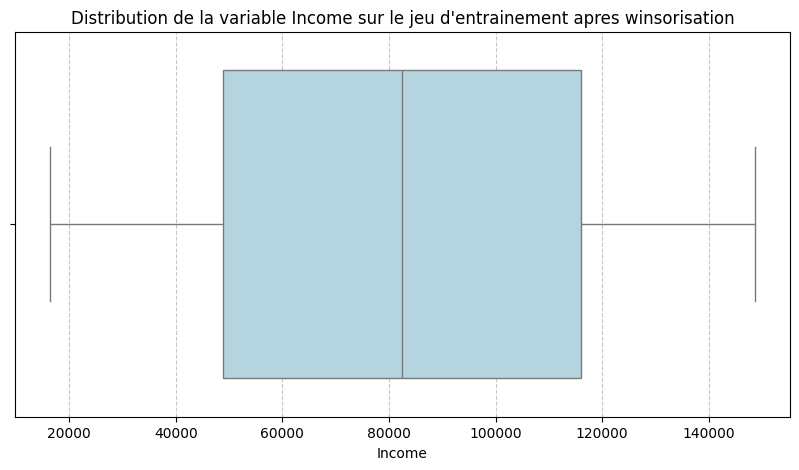

In [ ]:
# Vérification visuelle de la distribution après traitement
variable_test = 'Income'

plt.figure(figsize=(10, 5))
sns.boxplot(x=ensembles['train'][variable_test], color='lightblue')
plt.title(f"Distribution de la variable {variable_test} sur le jeu d'entrainement apres winsorisation")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Sauvegarde des partitions nettoyées
dossier_export = os.path.join(DOSSIER_RACINE, 'data_cleaned')
os.makedirs(dossier_export, exist_ok=True)

ensembles['train'].to_csv(os.path.join(dossier_export, 'train.csv'), index=False, sep=';')
ensembles['val'].to_csv(os.path.join(dossier_export, 'val.csv'), index=False, sep=';')
ensembles['test'].to_csv(os.path.join(dossier_export, 'test.csv'), index=False, sep=';')

print(f"Exportation des donnees terminee dans le repertoire : {dossier_export}")

Exportation des donnees terminee dans le repertoire : data_cleaned


In [ ]:
#Chargement des données nettoyées et séparation de la cible
dossier_entree = os.path.join(DOSSIER_RACINE, 'data_cleaned')

df_train = pd.read_csv(os.path.join(dossier_entree, 'train.csv'), sep=';')
df_val = pd.read_csv(os.path.join(dossier_entree, 'val.csv'), sep=';')
df_test = pd.read_csv(os.path.join(dossier_entree, 'test.csv'), sep=';')

cible = 'Default'

y_train = df_train[cible].copy()
y_val = df_val[cible].copy()
y_test = df_test[cible].copy()

X_train = df_train.drop(columns=[cible])
X_val = df_val.drop(columns=[cible])
X_test = df_test.drop(columns=[cible])

print(f"Chargement effectue. Dimensions initiales X_train : {X_train.shape}")

Chargement effectue. Dimensions initiales X_train : (178735, 16)


In [ ]:
#Identification et encodage des variables catégorielles
colonnes_categorielles = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

encodeur = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encodeur.fit(X_train[colonnes_categorielles])

noms_colonnes_encodees = encodeur.get_feature_names_out(colonnes_categorielles)

X_train_cat = pd.DataFrame(encodeur.transform(X_train[colonnes_categorielles]), columns=noms_colonnes_encodees, index=X_train.index)
X_val_cat = pd.DataFrame(encodeur.transform(X_val[colonnes_categorielles]), columns=noms_colonnes_encodees, index=X_val.index)
X_test_cat = pd.DataFrame(encodeur.transform(X_test[colonnes_categorielles]), columns=noms_colonnes_encodees, index=X_test.index)

print(f"Encodage termine. Nombre de variables categorielles creees : {len(noms_colonnes_encodees)}")

Encodage termine. Nombre de variables categorielles creees : 22


In [ ]:
#Mise à l'échelle des variables continues
colonnes_continues = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

standardiseur = StandardScaler()
standardiseur.fit(X_train[colonnes_continues])

X_train_num = pd.DataFrame(standardiseur.transform(X_train[colonnes_continues]), columns=colonnes_continues, index=X_train.index)
X_val_num = pd.DataFrame(standardiseur.transform(X_val[colonnes_continues]), columns=colonnes_continues, index=X_val.index)
X_test_num = pd.DataFrame(standardiseur.transform(X_test[colonnes_continues]), columns=colonnes_continues, index=X_test.index)

print("Standardisation terminee.")

Standardisation terminee.


In [ ]:
#Recombinaison et exportation des artefacts
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_final = pd.concat([X_val_num, X_val_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

df_train_final = pd.concat([X_train_final, y_train], axis=1)
df_val_final = pd.concat([X_val_final, y_val], axis=1)
df_test_final = pd.concat([X_test_final, y_test], axis=1)

dossier_export = 'data_transformed'
os.makedirs(dossier_export, exist_ok=True)

df_train_final.to_csv(os.path.join(dossier_export, 'train_transformed.csv'), index=False, sep=';')
df_val_final.to_csv(os.path.join(dossier_export, 'val_transformed.csv'), index=False, sep=';')
df_test_final.to_csv(os.path.join(dossier_export, 'test_transformed.csv'), index=False, sep=';')

joblib.dump(encodeur, os.path.join(dossier_export, 'encodeur.joblib'))
joblib.dump(standardiseur, os.path.join(dossier_export, 'standardiseur.joblib'))

print(f"Exportation terminee dans le repertoire : {dossier_export}")
print(f"Nouvelles dimensions du jeu d'entrainement : {df_train_final.shape}")

Exportation terminee dans le repertoire : data_transformed
Nouvelles dimensions du jeu d'entrainement : (178735, 32)


In [ ]:
#Chargement des données nettoyées et séparation de la cible
dossier_entree = os.path.join(DOSSIER_RACINE, 'data_cleaned')

df_train = pd.read_csv(os.path.join(dossier_entree, 'train.csv'), sep=';')
df_val = pd.read_csv(os.path.join(dossier_entree, 'val.csv'), sep=';')
df_test = pd.read_csv(os.path.join(dossier_entree, 'test.csv'), sep=';')

cible = 'Default'

y_train = df_train[cible].copy()
y_val = df_val[cible].copy()
y_test = df_test[cible].copy()

X_train = df_train.drop(columns=[cible])
X_val = df_val.drop(columns=[cible])
X_test = df_test.drop(columns=[cible])

print(f"Chargement effectue. Dimensions initiales X_train : {X_train.shape}")

Chargement effectue. Dimensions initiales X_train : (178735, 16)


In [ ]:
#Identification et encodage des variables catégorielles
colonnes_categorielles = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

encodeur = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encodeur.fit(X_train[colonnes_categorielles])

noms_colonnes_encodees = encodeur.get_feature_names_out(colonnes_categorielles)

X_train_cat = pd.DataFrame(encodeur.transform(X_train[colonnes_categorielles]), columns=noms_colonnes_encodees, index=X_train.index)
X_val_cat = pd.DataFrame(encodeur.transform(X_val[colonnes_categorielles]), columns=noms_colonnes_encodees, index=X_val.index)
X_test_cat = pd.DataFrame(encodeur.transform(X_test[colonnes_categorielles]), columns=noms_colonnes_encodees, index=X_test.index)

print(f"Encodage termine. Nombre de variables categorielles creees : {len(noms_colonnes_encodees)}")

Encodage termine. Nombre de variables categorielles creees : 22


In [ ]:
#Mise à l'échelle des variables continues
colonnes_continues = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

standardiseur = StandardScaler()
standardiseur.fit(X_train[colonnes_continues])

X_train_num = pd.DataFrame(standardiseur.transform(X_train[colonnes_continues]), columns=colonnes_continues, index=X_train.index)
X_val_num = pd.DataFrame(standardiseur.transform(X_val[colonnes_continues]), columns=colonnes_continues, index=X_val.index)
X_test_num = pd.DataFrame(standardiseur.transform(X_test[colonnes_continues]), columns=colonnes_continues, index=X_test.index)

print("Standardisation terminee.")

Standardisation terminee.


In [ ]:
#Recombinaison et exportation des artefacts
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_val_final = pd.concat([X_val_num, X_val_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

df_train_final = pd.concat([X_train_final, y_train], axis=1)
df_val_final = pd.concat([X_val_final, y_val], axis=1)
df_test_final = pd.concat([X_test_final, y_test], axis=1)

dossier_export = DOSSIER_TRANSFORMED
os.makedirs(dossier_export, exist_ok=True)

df_train_final.to_csv(os.path.join(dossier_export, 'train_transformed.csv'), index=False, sep=';')
df_val_final.to_csv(os.path.join(dossier_export, 'val_transformed.csv'), index=False, sep=';')
df_test_final.to_csv(os.path.join(dossier_export, 'test_transformed.csv'), index=False, sep=';')

joblib.dump(encodeur, os.path.join(dossier_export, 'encodeur.joblib'))
joblib.dump(standardiseur, os.path.join(dossier_export, 'standardiseur.joblib'))

print(f"Exportation terminee dans le repertoire : {dossier_export}")
print(f"Nouvelles dimensions du jeu d'entrainement : {df_train_final.shape}")

Exportation terminee dans le repertoire : data_transformed
Nouvelles dimensions du jeu d'entrainement : (178735, 32)


In [ ]:
#Chargement des données transformées
dossier_entree = DOSSIER_TRANSFORMED

df_train = pd.read_csv(os.path.join(dossier_entree, 'train_transformed.csv'), sep=';')
df_val = pd.read_csv(os.path.join(dossier_entree, 'val_transformed.csv'), sep=';')
df_test = pd.read_csv(os.path.join(dossier_entree, 'test_transformed.csv'), sep=';')

cible = 'Default'

print(f"Chargement effectue. Dimensions du jeu d'entrainement : {df_train.shape}")

Chargement effectue. Dimensions du jeu d'entrainement : (178735, 32)


In [ ]:
#Création du pipeline tf.data.Dataset
BATCH_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE

def creer_dataset(dataframe, cible, shuffle=False, batch_size=256):
    """
    Convertit un DataFrame pandas en tf.data.Dataset asynchrone et optimisé.
    """
    labels = dataframe[cible].astype('float32').values
    features = dataframe.drop(columns=[cible]).astype('float32').values
    
    ds = tf.data.Dataset.from_tensor_slices((features, labels))
    ds = ds.cache()
    
    if shuffle:
        ds = ds.shuffle(buffer_size=len(features), reshuffle_each_iteration=True)
        
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    
    return ds

train_ds = creer_dataset(df_train, cible, shuffle=True, batch_size=BATCH_SIZE)
val_ds = creer_dataset(df_val, cible, shuffle=False, batch_size=BATCH_SIZE)
test_ds = creer_dataset(df_test, cible, shuffle=False, batch_size=BATCH_SIZE)

print("Pipelines tf.data.Dataset crees avec succes.")

E0000 00:00:1774448581.695490   18580 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774448581.701690   19024 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1774448581.751146   18580 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Pipelines tf.data.Dataset crees avec succes.


In [ ]:
#Procédure de validation et tests unitaires du pipeline
def valider_pipeline(dataset, batch_size_attendu, nb_features_attendu):
    """
    Test unitaire strict pour valider l'intégrité des tenseurs générés par le pipeline en isolation.
    """
    try:
        batches = list(dataset.take(1))
        assert len(batches) > 0, "Erreur critique : Le dataset est vide ou non itérable."
        
        x_batch, y_batch = batches[0]
        
        assert x_batch.shape[0] == batch_size_attendu, f"Erreur de dimension : Batch size {x_batch.shape[0]}, attendu {batch_size_attendu}"
        assert x_batch.shape[1] == nb_features_attendu, f"Erreur de dimension : Features {x_batch.shape[1]}, attendu {nb_features_attendu}"
        assert len(y_batch.shape) == 1, "Erreur structurelle : Les labels doivent être un vecteur 1D"
        
        assert x_batch.dtype == tf.float32, f"Erreur de type : Attendu tf.float32, obtenu {x_batch.dtype}"
        assert y_batch.dtype == tf.float32, f"Erreur de type : Attendu tf.float32, obtenu {y_batch.dtype}"
        
        assert not tf.math.reduce_any(tf.math.is_nan(x_batch)), "Erreur de valeur : Présence de NaN dans la matrice de caractéristiques"
        assert not tf.math.reduce_any(tf.math.is_nan(y_batch)), "Erreur de valeur : Présence de NaN dans le vecteur cible"
        
        # Vérification mathématique de la variance pour s'assurer que les données ne sont pas altérées en un vecteur uniforme
        variance_batch = tf.math.reduce_std(x_batch)
        assert variance_batch > 0.0, "Erreur mathématique : La variance du lot est nulle."
        
        print("Validation unitaire réussie. Pipeline opérationnel et stable.")
        print("Shape de la matrice de caractéristiques (X) :", x_batch.shape)
        print("Type de données (X) :", x_batch.dtype)
        
    except AssertionError as e:
        print(f"ECHEC DU TEST UNITAIRE : {e}")
        raise

nb_features = df_train.shape[1] - 1
valider_pipeline(train_ds, BATCH_SIZE, nb_features)

Validation unitaire réussie. Pipeline opérationnel et stable.
Shape de la matrice de caractéristiques (X) : (256, 31)
Type de données (X) : <dtype: 'float32'>


In [ ]:
#Sauvegarde des graphes TensorFlow et validation du chargement
dossier_tf = DOSSIER_TF
os.makedirs(dossier_tf, exist_ok=True)

# Sauvegarde au format natif tf.data
train_ds.save(os.path.join(dossier_tf, 'train'))
val_ds.save(os.path.join(dossier_tf, 'val'))
test_ds.save(os.path.join(dossier_tf, 'test'))

def valider_chargement_pipeline(chemin_acces, batch_size_attendu, nb_features_attendu):
    """
    Validation de la persistance des données sur le disque dur.
    """
    try:
        ds_charge = tf.data.Dataset.load(chemin_acces)
        element_spec = ds_charge.element_spec
        
        # Vérification de la signature des tenseurs rechargés
        assert element_spec[0].shape == (None, nb_features_attendu), "Erreur de dimension lors du rechargement des caractéristiques."
        assert element_spec[1].shape == (None,), "Erreur de dimension lors du rechargement de la cible."
        
        print(f"Validation du chargement réussie pour le répertoire : {chemin_acces}")
    except Exception as e:
        print(f"ECHEC DE LA VALIDATION DU CHARGEMENT : {e}")
        raise

valider_chargement_pipeline(os.path.join(dossier_tf, 'train'), BATCH_SIZE, nb_features)

Validation du chargement réussie pour le répertoire : data_tf_pipelines/train


In [ ]:
#Rechargement des pipelines de données
dossier_tf = DOSSIER_TF

train_ds = tf.data.Dataset.load(os.path.join(dossier_tf, 'train'))
val_ds = tf.data.Dataset.load(os.path.join(dossier_tf, 'val'))
test_ds = tf.data.Dataset.load(os.path.join(dossier_tf, 'test'))

def valider_et_extraire_dimension(dataset):
    """Vérifie la structure du dataset et extrait dynamiquement le nombre de features."""
    element_spec = dataset.element_spec
    shape_x = element_spec[0].shape
    shape_y = element_spec[1].shape
    
    assert len(shape_x) == 2, "La matrice de caractéristiques doit être 2D (Batch, Features)."
    assert shape_y == (None,), "Le vecteur cible doit être 1D."
    
    nb_features = shape_x[1]
    assert nb_features > 0, "Le nombre de caractéristiques doit être strictement positif."
    
    print(f"Validation réussie. Dimension d'entrée détectée : {nb_features} caractéristiques.")
    return nb_features

NB_FEATURES = valider_et_extraire_dimension(train_ds)

Validation réussie. Dimension d'entrée détectée : 31 caractéristiques.


In [ ]:
def calculer_poids_classes(dataset):
    """Extrait les étiquettes et calcule les poids pour pénaliser les erreurs sur la classe minoritaire."""
    # Aplatissement explicite pour s'assurer d'un tableau 1D
    y_true = np.concatenate([y.numpy().flatten() for x, y in dataset])
    classes = np.unique(y_true)
    poids = compute_class_weight(class_weight='balanced', classes=classes, y=y_true)
    
    # Cast explicite en int et float natifs exigé par Keras pour l'association des poids
    class_weights_dict = {int(c): float(p) for c, p in zip(classes, poids)}
    return class_weights_dict, y_true

class_weights, y_train_labels = calculer_poids_classes(train_ds)

def valider_poids(poids_dict, labels):
    """Vérifie que la classe minoritaire reçoit un poids mathématiquement supérieur."""
    ratio_defaut = np.sum(labels == 1) / len(labels)
    assert 0 in poids_dict and 1 in poids_dict, "Les deux classes (0 et 1) doivent avoir un poids."
    
    if ratio_defaut < 0.5:
        assert poids_dict[1] > poids_dict[0], "Erreur : La classe minoritaire (1) n'est pas suffisamment pénalisée."
    print("Validation des poids réussie :", poids_dict)

valider_poids(class_weights, y_train_labels)

Validation des poids réussie : {0: 0.5656922755556119, 1: 4.305622470610908}


In [ ]:
def creer_baseline(nb_features):
    """Construit un Perceptron Multicouche simple avec Batch Normalization et Dropout."""
    entree = keras.Input(shape=(nb_features,))
    
    x = keras.layers.Dense(64, activation='relu')(entree)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.2)(x)
    
    sortie = keras.layers.Dense(1, activation='sigmoid')(x)
    
    modele = keras.Model(inputs=entree, outputs=sortie, name="Baseline_MLP")
    
    metriques = [
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.AUC(name='auc', curve='PR')
    ]
    
    modele.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=metriques
    )
    return modele

def valider_architecture_baseline():
    """Test unitaire : vérifie la compilation du graphe et la validité de la fonction de sortie."""
    modele = creer_baseline(NB_FEATURES)
    tenseur_test = tf.random.normal((1, NB_FEATURES))
    prediction = modele(tenseur_test)
    
    assert prediction.shape == (1, 1), f"Erreur de dimension de sortie : {prediction.shape}"
    assert 0.0 <= float(prediction.numpy()[0][0]) <= 1.0, "Erreur : La sortie sigmoïde doit être comprise entre 0 et 1."
    assert isinstance(modele.loss, keras.losses.BinaryCrossentropy), "Erreur : La fonction de perte n'est pas BinaryCrossentropy."
    
    print("Validation de l'architecture réussie. Le graphe compile correctement.")

valider_architecture_baseline()

Validation de l'architecture réussie. Le graphe compile correctement.


In [ ]:
def obtenir_callbacks(nom_experience):
    """Configure les callbacks pour la sauvegarde et l'arrêt prématuré."""
    chemin_modele = os.path.join(DOSSIER_MODELES, f"{nom_experience}.keras")
    chemin_log = os.path.join(DOSSIER_LOGS, nom_experience)
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_recall', mode='max', patience=10, restore_best_weights=True, verbose=1
    )
    
    model_checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=chemin_modele, monitor='val_recall', mode='max', save_best_only=True, verbose=0
    )
    
    tensorboard = keras.callbacks.TensorBoard(log_dir=chemin_log, histogram_freq=1)
    
    return [early_stopping, model_checkpoint, tensorboard]

def valider_callbacks():
    """Vérifie l'instanciation correcte des objets callbacks."""
    cb_list = obtenir_callbacks("test_cb")
    assert any(isinstance(cb, keras.callbacks.EarlyStopping) for cb in cb_list), "EarlyStopping manquant."
    assert any(isinstance(cb, keras.callbacks.ModelCheckpoint) for cb in cb_list), "ModelCheckpoint manquant."
    print("Validation des callbacks réussie.")

valider_callbacks()

Validation des callbacks réussie.


In [ ]:
def entrainer_baseline():
    """Encapsule l'entraînement du modèle de référence."""
    baseline_model = creer_baseline(NB_FEATURES)
    callbacks_baseline = obtenir_callbacks("baseline_mlp")

    print("Début de l'entraînement de la Baseline...")
    historique = baseline_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        class_weight=class_weights,
        callbacks=callbacks_baseline,
        verbose=1
    )
    return baseline_model

baseline_model_entraine = entrainer_baseline()

def valider_inference(modele, dataset_test):
    """Test unitaire post-entraînement : vérifie que le modèle produit des probabilités valides sur un lot de test."""
    for x_batch, y_batch in dataset_test.take(1):
        predictions = modele.predict(x_batch, verbose=0)
        assert predictions.shape == (x_batch.shape[0], 1), "Dimension des prédictions incorrecte."
        assert np.all((predictions >= 0.0) & (predictions <= 1.0)), "Des probabilités hors de l'intervalle [0, 1] ont été détectées."
    print("Validation d'inférence réussie. Le modèle prédit correctement sur des données non vues.")

valider_inference(baseline_model_entraine, test_ds)

Début de l'entraînement de la Baseline...
Epoch 1/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - auc: 0.2338 - loss: 0.6413 - precision: 0.1911 - recall: 0.6658 - val_auc: 0.2991 - val_loss: 0.5892 - val_precision: 0.2187 - val_recall: 0.6820
Epoch 2/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.2826 - loss: 0.6021 - precision: 0.2133 - recall: 0.6834 - val_auc: 0.3082 - val_loss: 0.5846 - val_precision: 0.2203 - val_recall: 0.6824
Epoch 3/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - auc: 0.2943 - loss: 0.5962 - precision: 0.2184 - recall: 0.6866 - val_auc: 0.3133 - val_loss: 0.5802 - val_precision: 0.2222 - val_recall: 0.6806
Epoch 4/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - auc: 0.3007 - loss: 0.5930 - precision: 0.2206 - recall: 0.6888 - val_auc: 0.3140 - val_loss: 0.5741 - val_precision: 0.2243 - val_recall: 0.6763
Epoch 5/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - auc: 0.3034 - loss: 0.5916 - precision: 0.2225 - recall: 0.6879 - val_auc: 0.3159 - val_loss: 0.5743 -

In [ ]:
def objective(trial):
    """Fonction objective pour l'optimisation des hyperparamètres."""
    keras.backend.clear_session()
    
    entree = keras.Input(shape=(NB_FEATURES,))
    
    nb_couches = trial.suggest_int("nb_couches", 1, 3)
    taux_apprentissage = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    
    x = entree
    for i in range(nb_couches):
        unites = trial.suggest_int(f"unites_couche_{i}", 32, 128, step=32)
        dropout = trial.suggest_float(f"dropout_couche_{i}", 0.1, 0.5)
        
        x = keras.layers.Dense(unites, activation='relu')(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Dropout(dropout)(x)
        
    sortie = keras.layers.Dense(1, activation='sigmoid')(x)
    modele = keras.Model(inputs=entree, outputs=sortie)
    
    modele.compile(
        optimizer=keras.optimizers.Adam(learning_rate=taux_apprentissage),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.Recall(name='recall')]
    )
    
    try:
        history = modele.fit(
            train_ds,
            validation_data=val_ds,
            epochs=15, 
            class_weight=class_weights,
            verbose=0
        )
    except Exception as e:
        # Permet à Optuna de continuer en cas d'erreur ponctuelle de calcul de gradient
        raise optuna.exceptions.TrialPruned() from e
    
    val_recall_max = max(history.history['val_recall'])
    return val_recall_max

def valider_et_lancer_optuna():
    """Valide l'initialisation de l'étude et lance la recherche."""
    tf.get_logger().setLevel('ERROR') 
    
    etude = optuna.create_study(direction="maximize", study_name="Optimisation_MLP_Defaut")
    print("Lancement de l'étude Optuna (3 essais de test)...")
    etude.optimize(objective, n_trials=3) 
    
    assert len(etude.trials) > 0, "L'étude Optuna n'a enregistré aucun essai."
    print("Validation Optuna réussie. Meilleurs hyperparamètres :", etude.best_params)

valider_et_lancer_optuna()

[I 2026-03-25 16:03:26,545] A new study created in memory with name: Optimisation_MLP_Defaut


Lancement de l'étude Optuna (3 essais de test)...


[I 2026-03-25 16:04:48,632] Trial 0 finished with value: 0.7170150876045227 and parameters: {'nb_couches': 3, 'learning_rate': 0.006687734244199542, 'unites_couche_0': 128, 'dropout_couche_0': 0.3227315626065822, 'unites_couche_1': 128, 'dropout_couche_1': 0.35915640457213127, 'unites_couche_2': 32, 'dropout_couche_2': 0.2848298841831045}. Best is trial 0 with value: 0.7170150876045227.
[I 2026-03-25 16:05:34,541] Trial 1 finished with value: 0.6808271408081055 and parameters: {'nb_couches': 3, 'learning_rate': 0.003479881504476611, 'unites_couche_0': 32, 'dropout_couche_0': 0.3029930636050667, 'unites_couche_1': 128, 'dropout_couche_1': 0.449045576709698, 'unites_couche_2': 32, 'dropout_couche_2': 0.38593053181900083}. Best is trial 0 with value: 0.7170150876045227.
[I 2026-03-25 16:06:38,116] Trial 2 finished with value: 0.710721492767334 and parameters: {'nb_couches': 3, 'learning_rate': 0.002129379487756628, 'unites_couche_0': 64, 'dropout_couche_0': 0.37377026145205494, 'unites_co

Validation Optuna réussie. Meilleurs hyperparamètres : {'nb_couches': 3, 'learning_rate': 0.006687734244199542, 'unites_couche_0': 128, 'dropout_couche_0': 0.3227315626065822, 'unites_couche_1': 128, 'dropout_couche_1': 0.35915640457213127, 'unites_couche_2': 32, 'dropout_couche_2': 0.2848298841831045}


In [ ]:
#Rechargement du modèle et des données de test
nom_modele = "baseline_mlp.keras" 
model = keras.models.load_model(os.path.join(DOSSIER_MODELES, nom_modele))

test_ds = tf.data.Dataset.load(os.path.join(DOSSIER_TF, 'test'))

def valider_chargement_evaluation(model, dataset):
    input_shape_model = model.input_shape[1]
    for x_batch, y_batch in dataset.take(1):
        input_shape_data = x_batch.shape[1]
        break
    assert input_shape_model == input_shape_data, f"Incohérence dimensionnelle : {input_shape_model} vs {input_shape_data}"
    print(f"Modèle '{model.name}' prêt pour l'inférence sur le jeu de test.")

valider_chargement_evaluation(model, test_ds)

Modèle 'Baseline_MLP' prêt pour l'inférence sur le jeu de test.


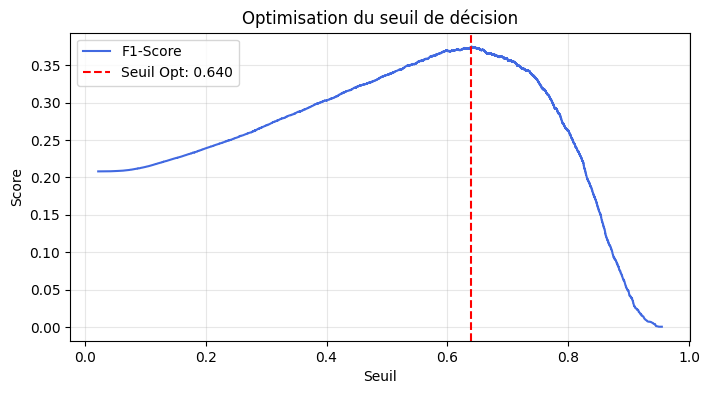

--- Rapport de Classification (Seuil : 0.640) ---
              precision    recall  f1-score   support

         0.0       0.93      0.85      0.88     33855
         1.0       0.30      0.50      0.37      4448

    accuracy                           0.81     38303
   macro avg       0.61      0.67      0.63     38303
weighted avg       0.86      0.81      0.83     38303



In [ ]:
#Inférence et recherche du seuil optimal
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_probs = model.predict(test_ds, verbose=0).flatten()

def evaluer_seuil_optimal(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    idx_opt = np.argmax(f1_scores)
    seuil_opt = thresholds[idx_opt] if idx_opt < len(thresholds) else thresholds[-1]
    
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f1_scores[:-1], label='F1-Score', color='royalblue')
    plt.axvline(seuil_opt, color='red', linestyle='--', label=f'Seuil Opt: {seuil_opt:.3f}')
    plt.title("Optimisation du seuil de décision")
    plt.xlabel("Seuil")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    y_pred_opt = (y_probs >= seuil_opt).astype(int)
    print(f"--- Rapport de Classification (Seuil : {seuil_opt:.3f}) ---")
    print(classification_report(y_true, y_pred_opt))
    
    return seuil_opt, y_pred_opt

seuil_optimal, y_pred_final = evaluer_seuil_optimal(y_true, y_probs)

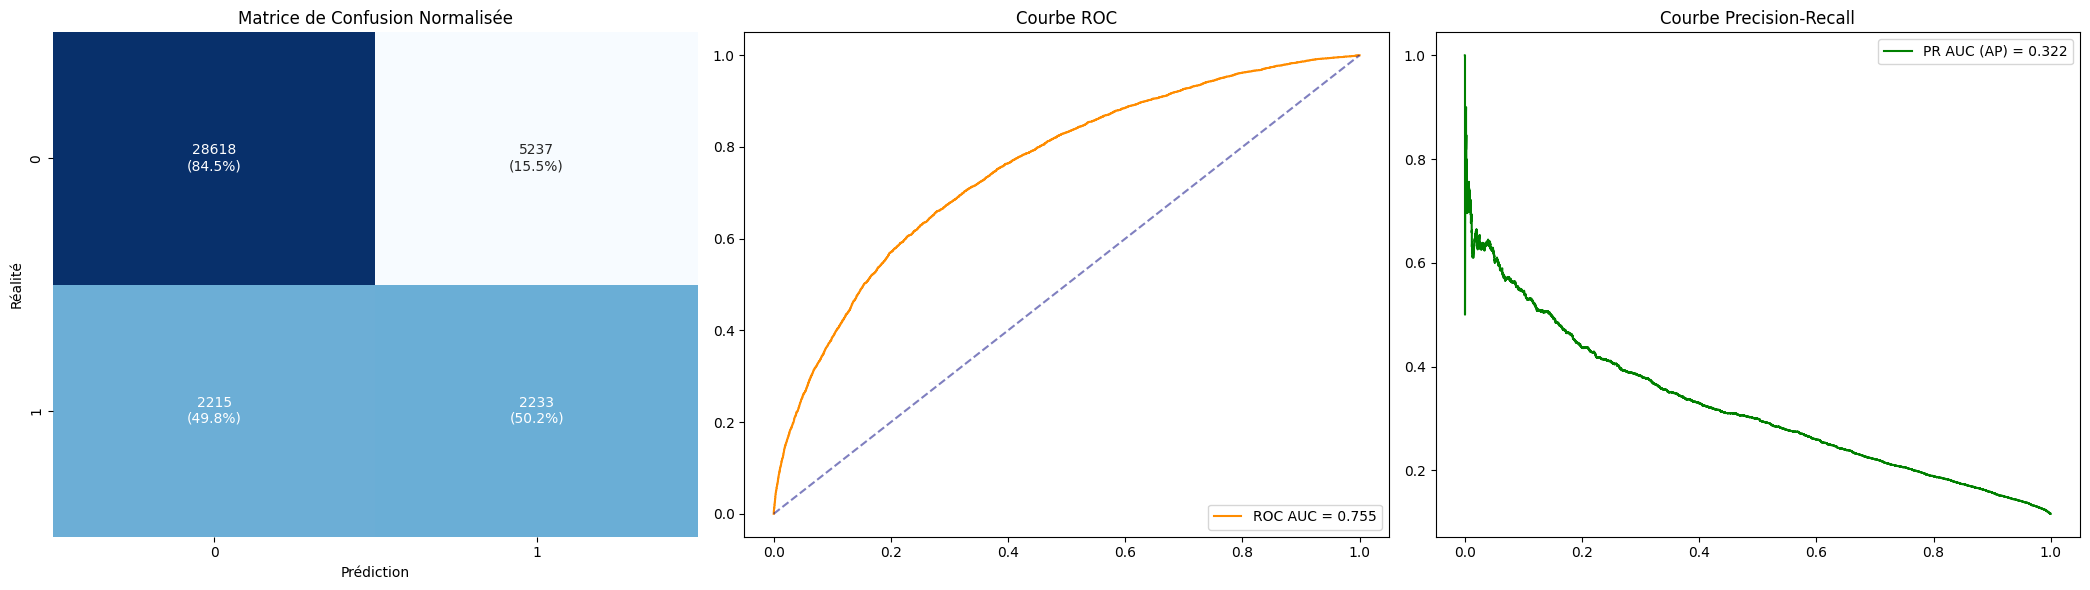

In [ ]:
#Analyse visuelle de performance (ROC et PR)
def tracer_performances_completes(y_true, y_probs, y_pred, seuil):
    fig, ax = plt.subplots(1, 3, figsize=(21, 6))
    
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    labels = (np.array(["{0:d}\n({1:.1%})".format(count, pct) 
              for count, pct in zip(cm.flatten(), cm_norm.flatten())])).reshape(2,2)
    
    sns.heatmap(cm_norm, annot=labels, fmt="", cmap='Blues', ax=ax[0], cbar=False)
    ax[0].set_title('Matrice de Confusion Normalisée')
    ax[0].set_xlabel('Prédiction')
    ax[0].set_ylabel('Réalité')
    
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    ax[1].plot(fpr, tpr, label=f'ROC AUC = {auc(fpr, tpr):.3f}', color='darkorange')
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='navy', alpha=0.5)
    ax[1].set_title('Courbe ROC')
    ax[1].legend(loc="lower right")
    
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    ap_score = average_precision_score(y_true, y_probs)
    ax[2].plot(recall, precision, label=f'PR AUC (AP) = {ap_score:.3f}', color='green')
    ax[2].set_title('Courbe Precision-Recall')
    ax[2].legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

tracer_performances_completes(y_true, y_probs, y_pred_final, seuil_optimal)

Importance globale des variables (Summary Plot) :


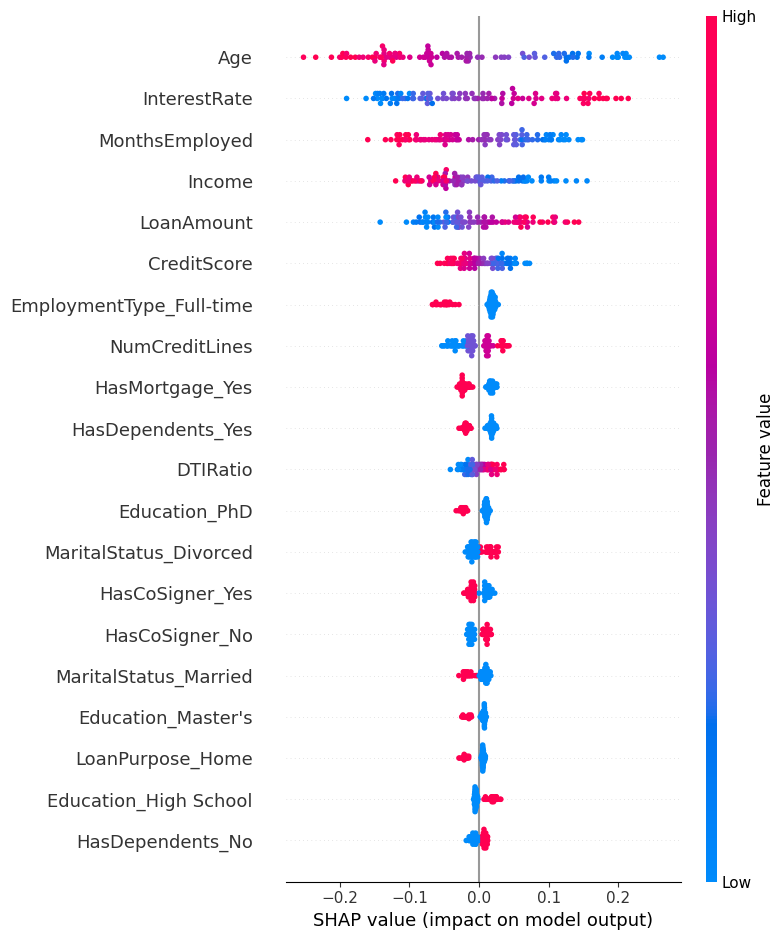

Validation réussie. Résultats sauvegardés : {'ROC_AUC': 0.7550420341617711, 'PR_AUC': 0.3216890732455864, 'Seuil_Optimal': 0.6395559906959534, 'F1_Score': 0.37472730323879844}


In [ ]:
# 1. Rechargement des noms de caractéristiques
X_train_ref = pd.read_csv(os.path.join(DOSSIER_TRANSFORMED, 'train_transformed.csv'), sep=';').drop(columns=['Default'])
feature_names = X_train_ref.columns.tolist()

# 2. Préparation des données pour SHAP
background = X_train_ref.sample(n=200, random_state=42).values.astype('float32')
X_test_eval = pd.read_csv(os.path.join(DOSSIER_TRANSFORMED, 'test_transformed.csv'), sep=';').drop(columns=['Default'])
X_explain_np = X_test_eval.sample(n=100, random_state=42).values.astype('float32')
X_explain_df = pd.DataFrame(X_explain_np, columns=feature_names)

# 3. Calcul des valeurs SHAP
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_explain_np)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[0]
else:
    shap_values_to_plot = shap_values

if len(shap_values_to_plot.shape) == 3:
    shap_values_to_plot = shap_values_to_plot[:, :, 0]

print("Importance globale des variables (Summary Plot) :")
shap.summary_plot(shap_values_to_plot, X_explain_df, plot_type="dot")

# 4. Correction : Recalcul des métriques pour la sauvegarde (Scope Global)
fpr_global, tpr_global, _ = roc_curve(y_true, y_probs)
ap_score_global = average_precision_score(y_true, y_probs)

metriques_finales = {
    "ROC_AUC": float(auc(fpr_global, tpr_global)),
    "PR_AUC": float(ap_score_global),
    "Seuil_Optimal": float(seuil_optimal),
    "F1_Score": float(f1_score(y_true, y_pred_final))
}

# 5. Exportation en JSON
chemin_metriques = 'performance_finale.json'
with open(chemin_metriques, 'w') as f:
    json.dump(metriques_finales, f)

# 6. Procédure de vérification unitaire
def valider_export_final(chemin):
    """Vérifie l'existence et l'intégrité du fichier de résultats."""
    assert os.path.exists(chemin), f"Erreur : Le fichier {chemin} est introuvable."
    with open(chemin, 'r') as f:
        data = json.load(f)
    for cle in ["ROC_AUC", "PR_AUC", "Seuil_Optimal", "F1_Score"]:
        assert cle in data, f"Erreur : La clé {cle} est manquante dans le fichier."
    print(f"Validation réussie. Résultats sauvegardés : {data}")

valider_export_final(chemin_metriques)

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Copier le modèle Keras dans le dossier models/ partagé
model.save('models/neural_net_model.keras')

# Sauvegarder les paramètres de normalisation en joblib
joblib.dump(encodeur, 'models/neural_net_encodeur.joblib')
joblib.dump(standardiseur, 'models/neural_net_standardiseur.joblib')

# Sauvegarder aussi les noms des colonnes continues et catégorielles
import json
params = {
    'colonnes_continues': colonnes_continues,
    'colonnes_categorielles': colonnes_categorielles,
    'seuil_optimal': float(seuil_optimal)
}
with open('models/neural_net_params.json', 'w') as f:
    json.dump(params, f)

print("Modèle réseau de neurones sauvegardé !")

NameError: name 'model' is not defined